In [ ]:
# [Dataset: IRIS dataset available in sklearn.datasets (take the
# columns sepal length and sepal width only as input features, and
# output classes should be Setosa vs. Virginica)]
# 1. Implement a decision tree to classify data samples based on given
# input features and analyze its performance using precision, recall,
# F1-score and accuracy.
# ● Load dataset and show basic statistics (mean, shape, output
# classes).
# ● Split the dataset into train and test sets (60:40).
# ● Train a decision tree classifier using:

# 1. gini index
# 2. information gain (entropy), with no max_depth
# parameter.

# ● Display the trained decision tree.
# ● Display the precision, recall, F1-score and accuracy obtained in
# both methods.

# 2. On the same dataset, implement Naive Bayes Classifier.
# ● Split the dataset into train and test sets (20:80).
# ● Train the classifier (from sklearn.naive_bayes library).
# ● Display the accuracy, precision, recall and F1-score obtained
# on test dataset.
# ● Display the confusion matrix as well.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

# Select only sepal length and sepal width
X = pd.DataFrame(iris.data, columns=iris.feature_names)[['sepal length (cm)', 'sepal width (cm)']]


# Target labels
y = pd.Series(iris.target, name="Class")

# Filter only Setosa (0) and Virginica (2)
mask = (y == 0) | (y == 2)
X = X[mask]
y = y[mask]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nClass names:")
for i, name in enumerate(iris.target_names):
    print(f"Class {i}: {name}")


Shape of X: (100, 2)
Shape of y: (100,)

Class names:
Class 0: setosa
Class 1: versicolor
Class 2: virginica


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

# Display shapes
print("Training set shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set shapes:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Training set shapes:
X_train: (60, 2)
y_train: (60,)

Testing set shapes:
X_test: (40, 2)
y_test: (40,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree classifier using Gini index
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train the model
dt_gini.fit(X_train, y_train)

print("Decision Tree trained successfully using Gini Index.")


Decision Tree trained successfully using Gini Index.


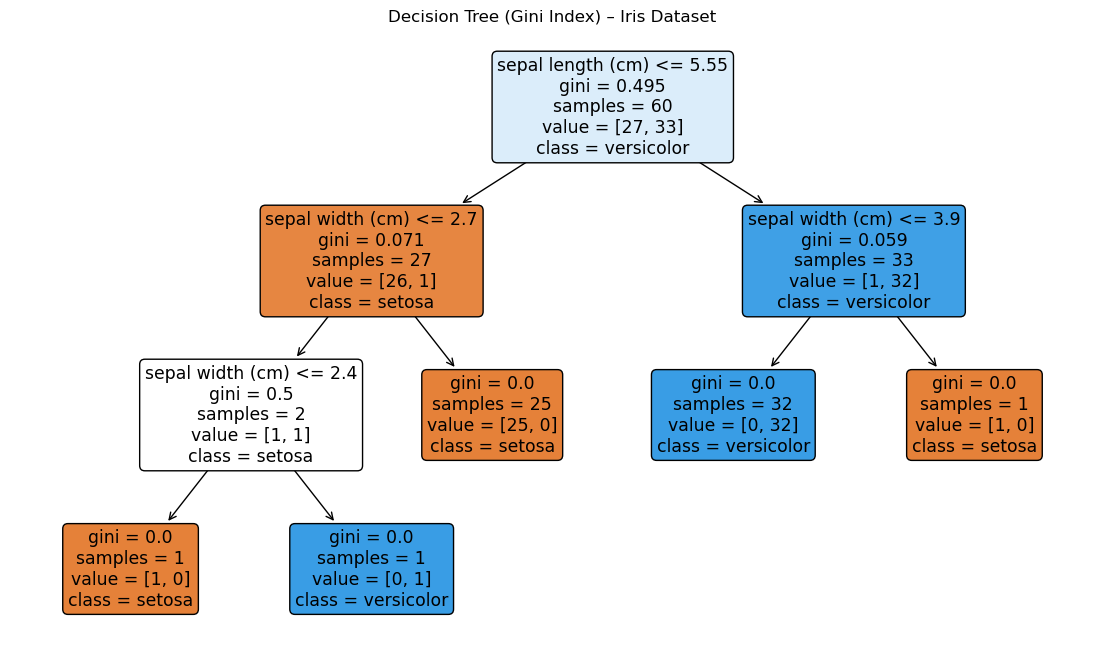

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plot_tree(
    dt_gini,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree (Gini Index) – Iris Dataset")
plt.show()


In [ ]:
# Predict class labels for test data
y_pred = dt_gini.predict(X_test)

print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test.values[:10])


Predicted labels: [2 2 2 0 0 0 0 2 0 0]
Actual labels:    [2 2 2 0 0 0 0 2 0 0]


In [ ]:
# Specify class names for the filtered binary dataset
class_names = ['Setosa', 'Virginica']

# Now generate the classification report
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      0.96      0.98        23
   Virginica       0.94      1.00      0.97        17

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifier using Information Gain (Entropy)
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

# Train the model
dt_entropy.fit(X_train, y_train)

print("Decision Tree trained successfully using Information Gain (Entropy).")


Decision Tree trained successfully using Information Gain (Entropy).


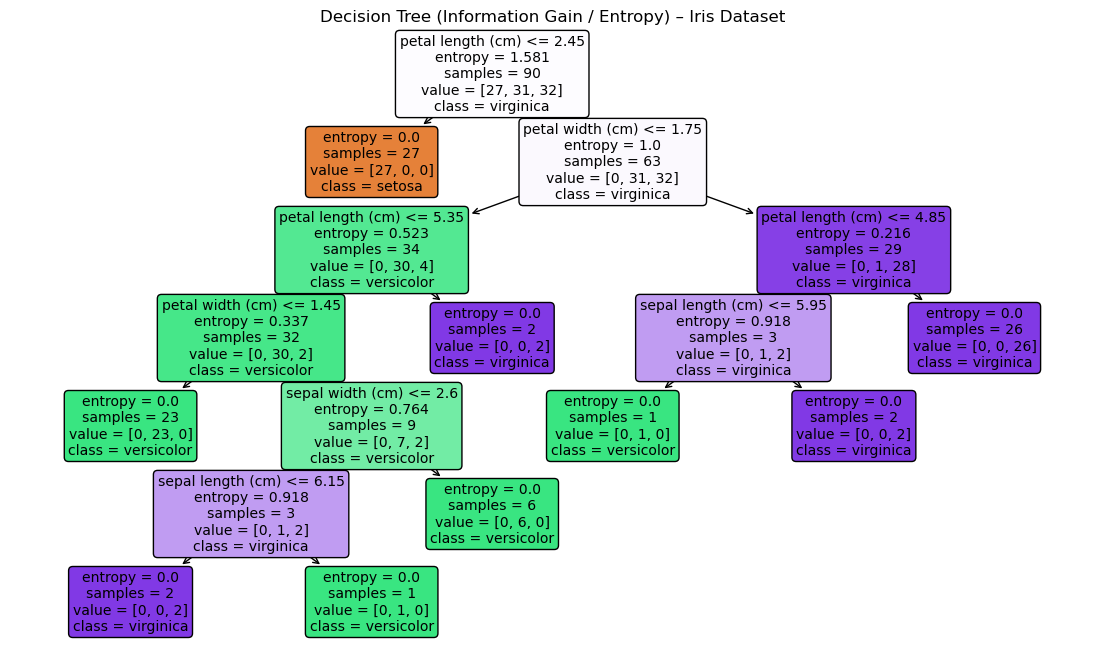

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plot_tree(
    dt_entropy,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree (Information Gain / Entropy) – Iris Dataset")
plt.show()


In [ ]:
# Predict using entropy-based model
y_pred_entropy = dt_entropy.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print("Accuracy (Entropy):", accuracy_entropy)

# Detailed report
print("\nClassification Report (Entropy):\n")
print(classification_report(
    y_test,
    y_pred_entropy,
    target_names=iris.target_names
))


Accuracy (Entropy): 0.9833333333333333

Classification Report (Entropy):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        23
  versicolor       0.95      1.00      0.97        19
   virginica       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

# Select only 'sepal length' and 'sepal width'
X = pd.DataFrame(iris.data, columns=iris.feature_names)[['sepal length (cm)', 'sepal width (cm)']]

# Target labels
y = pd.Series(iris.target, name="Class")

# Filter Setosa (0) and Virginica (2)
mask = (y == 0) | (y == 2)
X = X[mask]
y = y[mask]

# Map classes to 0 and 1
y = y.map({0:0, 2:1})

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Unique classes:", y.unique())


Shape of X: (100, 2)
Shape of y: (100,)
Unique classes: [0 1]


In [ ]:
X

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.8,
    random_state=42,
    shuffle=True
)

print("Training set shapes:", X_train.shape, y_train.shape)
print("Testing set shapes:", X_test.shape, y_test.shape)


Training set shapes: (20, 2) (20,)
Testing set shapes: (80, 2) (80,)


In [ ]:
# Initialize Gaussian Naïve Bayes
nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)

print("Naïve Bayes model trained successfully.")


Naïve Bayes model trained successfully.


In [ ]:
y_pred = nb.predict(X_test)


In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Setosa','Virginica']
))


Accuracy: 0.9875

Classification Report:

              precision    recall  f1-score   support

      Setosa       0.98      1.00      0.99        42
   Virginica       1.00      0.97      0.99        38

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[42  0]
 [ 1 37]]
